# Efficiency (MC cuts)

In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm
from functools import reduce
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import gc
import itertools
import glob
import os
import math

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

# Global parameters
acceptance = 0.8


# Generated Particles

In [2]:
base_path = "/home/pira/Documenti/PoD/LCP/LCP_B/ALICE/Simulation"
which_chunk = ["001_010", "011_020", "021_030", "031_040", "041_050", "051_060", "061_070", "071_080", "081_090", "091_100" ]
which_file = "AO2Dtree.root"

# Lists to store results
gen_particles = []
gen_anti_particles = []
gen_D_0 = 0
#test_eta_mother = []
#test_eta_daugther = []


# file by file...
for chunk in which_chunk:
    file = uproot.open(base_path + "/" + chunk + "/" + which_file)
    all_files = file.keys(filter_name = r"DF_*")
    file_ID = list(set([code.split("/")[0] for code in all_files]))
    # remove the directoryes code
    file_ID = [s for s in file_ID if not s.endswith(";1")]



    for directory in file_ID:
    
        # merge the genparticles an mccollision dataframes on fIndexMcCollisions
        generated_part = file[directory + "/O2genparticles"].arrays(library="pd")
        mc_collision_df = file[directory + "/O2mccollision"].arrays(library="pd")
        generated_part = pd.merge(left=generated_part, right=mc_collision_df, how='inner', left_on='fIndexMcCollisions', right_index=True)
        #test_eta_daugther.append(generated_part["fMaxEtaDaughter"])
        #test_eta_mother.append(generated_part["fMainMotherY"])

        
        # DEFINING MASKS to decrease the number of columns by summarizing them:
        mask_true_d0 = (
            (generated_part["fPosZ"].abs() < 10) &
            (generated_part["fMainMotherY"].abs() < acceptance) &
            (generated_part["fPdgCode"] == 421) &
            (generated_part["fMainBeautyAncestorPdgCode"] == 0) 
        )
        
        mask_true_anti_d0 = (
            (generated_part["fPosZ"].abs() < 10) &
            (generated_part["fMainMotherY"].abs() < acceptance) &
            (generated_part["fPdgCode"] == -421) &
            (generated_part["fMainBeautyAncestorPdgCode"] == 0) 
        )
    
        # apply the mask
        generated_part_true_d0 = generated_part[mask_true_d0]
        generated_part_true_anti_d0 = generated_part[mask_true_anti_d0]
        
        # count the generated particles selected after the cuts file by file
        n_gen_D_0 = len(generated_part_true_d0)+len(generated_part_true_anti_d0)
        #print("In this file there are", len(generated_part_true_d0), "D_0", len(generated_part_true_anti_d0), "anti-D0")
    
        # Update the total number of generated particles
        gen_D_0 += n_gen_D_0 
    
        gen_particles.append(generated_part_true_d0)
        gen_anti_particles.append(generated_part_true_anti_d0)

In [3]:
tot_list_gen = gen_particles + gen_anti_particles 
tot_df_gen = pd.concat(tot_list_gen, ignore_index=True)
tot_df_gen.tail(10)

,fPdgCode,fIndexMcCollisions,fMainBeautyAncestorPdgCode,fMainMotherPt,fMainMotherY,fMaxEtaDaughter,fMainBeautyAncestorPt,fMainBeautyAncestorY,fIndexBCs,fGeneratorsID,fPosX,fPosY,fPosZ,fT,fWeight,fImpactParameter
329676,-421,672,0,1.104976,0.480963,1.220658,0.0,0.0,6086,2175,-0.037106,-0.019878,0.853230,6.882692e+13,1.0,0.0
329677,-421,730,0,0.229587,0.768539,1.596946,0.0,0.0,6596,10367,-0.034524,-0.017423,3.092361,6.882692e+13,1.0,0.0
329678,-421,765,0,5.775868,-0.643341,0.865219,0.0,0.0,6924,12415,-0.032522,-0.034338,2.969933,6.882692e+13,1.0,0.0
329679,-421,777,0,2.214746,-0.420248,1.241878,0.0,0.0,7057,2175,-0.041361,-0.011095,-4.756256,6.882692e+13,1.0,0.0
329680,-421,797,0,0.521953,-0.360629,2.826133,0.0,0.0,7246,2175,-0.039750,-0.022432,-5.195740,6.882692e+13,1.0,0.0
329681,-421,832,0,2.163589,-0.268284,0.905643,0.0,0.0,7564,2175,-0.018191,-0.025537,9.017319,6.882692e+13,1.0,0.0
329682,-421,857,0,0.656607,-0.260387,1.197428,0.0,0.0,7765,2175,-0.030852,-0.019740,4.517342,6.882692e+13,1.0,0.0
329683,-421,862,0,2.684488,-0.781038,1.665648,0.0,0.0,7827,2175,-0.037578,-0.025308,-3.324089,6.882692e+13,1.0,0.0
329684,-421,890,0,1.864087,0.394570,0.660908,0.0,0.0,8073,10367,-0.041127,-0.018479,0.889896,6.882692e+13,1.0,0.0
329685,-421,899,0,6.943466,0.640064,0.795552,0.0,0.0,8147,2175,-0.044265,-0.028371,-3.047951,6.882692e+13,1.0,0.0


In [4]:
# Pt intervals and labels
Pt_intervals = [0, 1, 3, 5, 8, 16]
Pt_labels = ["0-1", "1-3", "3-5", "5-8", "8-16"]

gen_D0_Pt = []
gen_anti_D0_Pt = []

# particles
for data_frame in gen_particles:
    data_frame = data_frame.copy()
    data_frame.loc[:,"interval"] = pd.cut(data_frame['fMainMotherPt'], bins=Pt_intervals, labels=Pt_labels, right=True, include_lowest=True)
    r = data_frame.groupby("interval", observed=True).size()
    gen_D0_Pt.append(r)

tot_D0_Pt = reduce(lambda x, y: x.add(y, fill_value=0), gen_D0_Pt)
tot_D0_Pt_df = tot_D0_Pt.reset_index()
tot_D0_Pt_df.columns = ['Pt_Interval', 'Count_D0']

#anti particles
for data_frame in gen_anti_particles:
    data_frame = data_frame.copy()
    data_frame.loc[:,"interval"] = pd.cut(data_frame['fMainMotherPt'], bins=Pt_intervals, labels=Pt_labels, right=True, include_lowest=True)
    r = data_frame.groupby("interval", observed=True).size()
    gen_anti_D0_Pt.append(r)

tot_anti_D0_Pt = reduce(lambda x, y: x.add(y, fill_value=0), gen_anti_D0_Pt)
tot_anti_D0_Pt_df = tot_anti_D0_Pt.reset_index()
tot_anti_D0_Pt_df.columns = ['Pt_Interval', 'Count_anti_D0']


In [5]:
tot_part = pd.merge(tot_D0_Pt_df, tot_anti_D0_Pt_df, on='Pt_Interval', how='inner')
tot_part["tot"] = tot_part["Count_D0"]+tot_part["Count_anti_D0"]
tot_gen_part = sum(tot_part["tot"])
tot_part 

,Pt_Interval,Count_D0,Count_anti_D0,tot
0,0-1,35107.0,34617.0,69724.0
1,1-3,83271.0,83425.0,166696.0
2,3-5,30615.0,30883.0,61498.0
3,5-8,11700.0,11631.0,23331.0
4,8-16,3850.0,3739.0,7589.0


In [6]:
print("The total number of particles generated in the MC simulation is:", tot_gen_part)

The total number of particles generated in the MC simulation is: 328838.0


# Reconstructed Particles

In [7]:
# directory where the files are stored
folder = "/home/pira/Documenti/PoD/LCP/LCP_B/ALICE/CombDataMC"
# CV directory for the data files
#folder = "/mnt/FilterResults/pairs_with_all_variabs"
all_files = glob.glob(os.path.join(folder, "*.pkl"))
# choose eventually which columns to exclude:
useless_cols = ['neg_fDcaXY', 'pos_fDcaXY']

# choose how many files to load
x = 90                             # change this to the number of files you want (or your RAM can afford... 4 Gb for the CV's VM)
files_to_load = all_files[:x]

print(f"Found {len(all_files)} files. Loading up to {len(files_to_load)} files")


Found 89 files. Loading up to 89 files


In [8]:
# initialization
final_results = pd.DataFrame()

# UPLOAD ---------------------------------------------------------------------
for i, f in enumerate(files_to_load, start=1):

    # import the data from the .pkl file
    df = pd.read_pickle(f)
    df = df.drop(columns=useless_cols)
    df = df[df['cos_pointing'] > 0.40] 

    
    # single track variables cuts --------------------------------------------------------------------------------
    new_Ka_hyp_neg = ( 
              ( (df["neg_pt"].between(0, 1.5)) & (df["neg_TOFka"].abs() < 5.67) & ( df["neg_TPCka"].abs() < 2.67 ) ) |
              ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_TOFka"].abs() < 7.64) & ( df["neg_TPCka"].abs() < 1.5 ) ) |
              ( (df["neg_pt"].between(0, 1.5)) & (df["neg_TOFka"]==-999) & ( df["neg_TPCka"].abs() < 1.67 ) ) |
              ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_TOFka"]==-999) & ( df["neg_TPCka"].abs() < 1.5 ) ) 
            )

    new_Ka_hyp_pos = (
                  ( (df["pos_pt"].between(0, 1.5)) & (df["pos_TOFka"].abs() < 5.67) & ( df["pos_TPCka"].abs() < 2.67 ) ) |
                  ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_TOFka"].abs() < 7.64) & ( df["pos_TPCka"].abs() < 1.5 ) ) |
                  ( (df["pos_pt"].between(0, 1.5)) & (df["pos_TOFka"]==-999) & ( df["pos_TPCka"].abs() < 1.67 ) ) |
                  ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_TOFka"]==-999) & ( df["pos_TPCka"].abs() < 1.5 ) )
                )
    
    new_Pi_hyp_neg = (
                  ( (df["neg_pt"].between(0, 1.5)) & (df["neg_TOFpi"].abs() < 11.97) & ( df["neg_TPCpi"].abs() < 3.33 ) ) |
                  ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_TOFpi"].abs() < 10.74) & ( df["neg_TPCpi"].abs() < 2.17 ) ) |
                  ( (df["neg_pt"].between(0, 1.5)) & (df["neg_TOFpi"]==-999) & ( df["neg_TPCpi"].abs() < 3.00 ) ) |
                  ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_TOFpi"]==-999) & ( df["neg_TPCpi"].abs() < 2.0 ) )
                )
    
    new_Pi_hyp_pos = (
                  ( (df["pos_pt"].between(0, 1.5)) & (df["pos_TOFpi"].abs() < 11.97) & ( df["pos_TPCpi"].abs() < 3.33 ) ) |
                  ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_TOFpi"].abs() < 10.74) & ( df["pos_TPCpi"].abs() < 2.17 ) ) |
                  ( (df["pos_pt"].between(0, 1.5)) & (df["pos_TOFpi"]==-999) & ( df["pos_TPCpi"].abs() < 3.00 ) ) |
                  ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_TOFpi"]==-999) & ( df["pos_TPCpi"].abs() < 2.0 ) )
                )

    new_undecided_neg = new_Ka_hyp_neg & new_Pi_hyp_neg
    new_undecided_pos = new_Ka_hyp_pos & new_Pi_hyp_pos
    new_undecided_hyp = new_undecided_neg & new_undecided_pos
    
    new_Ka_hyp = new_Ka_hyp_neg | new_Ka_hyp_pos
    new_Pi_hyp = new_Pi_hyp_pos | new_Pi_hyp_neg
    
    new_D0_sure_hyp = new_Ka_hyp_neg & new_Pi_hyp_pos
    new_D0_uncert_hyp = ( (new_undecided_neg & new_Pi_hyp_pos) | (new_undecided_pos & new_Ka_hyp_neg) )
    new_D0 = new_D0_sure_hyp | new_D0_uncert_hyp
    
    new_antiD0_sure_hyp = new_Ka_hyp_pos & new_Pi_hyp_neg
    new_antiD0_uncert_hyp = ( (new_undecided_neg & new_Ka_hyp_pos) | (new_undecided_pos & new_Pi_hyp_neg) )
    new_antiD0 = new_antiD0_sure_hyp | new_antiD0_uncert_hyp
    
    # DEFINING MASKS to decrease the number of columns by summarizing them:
    mask_true_d0 = (
        (df["track_pdg_pos"] == 211 ) &
        (df["track_pdg_neg"] == -321 ) &
        (df["mother_pdg_pos"] == 421) &
        (df["mother_pdg_neg"] == 421) &
        (df["beauty_pdg_pos"] == 0) &
        (df["beauty_pdg_neg"] == 0) &
        (df["mother_N_final_state_pos"] == 2) &
        (df["mother_N_final_state_neg"] == 2) &
        (df['mother_orig_ind_pos'] == df['mother_orig_ind_neg'] )
    )
    mask_true_anti_d0 = (
        (df["track_pdg_pos"] == 321) &
        (df["track_pdg_neg"] == -211) &
        (df["mother_pdg_pos"] == -421) &
        (df["mother_pdg_neg"] == -421) &
        (df["beauty_pdg_pos"] == 0) &
        (df["beauty_pdg_neg"] == 0) &
        (df["mother_N_final_state_pos"] == 2) &
        (df["mother_N_final_state_neg"] == 2) &
        (df['mother_orig_ind_pos'] == df['mother_orig_ind_neg'] )
    )
    mask_background = ( (~mask_true_d0) & (~mask_true_anti_d0) )

    # apply the same masks as data------------------------------------------------------------------------------------------------------
    df["hyp"] = np.select( condlist = [new_undecided_hyp, new_D0, new_antiD0 ],
                                    choicelist=["Undecided", "D0", "Anti-D0"], default = "Bkg" )

    # SUMMARIZE some columns and apply the MC masks-------------------------------------------------------------------------------------
    df["truth"] = np.select( condlist = [mask_true_d0, mask_true_anti_d0] , 
                             choicelist = [1, -1], default = 0)

    summarized_cols = ["track_pdg_pos", "track_pdg_neg", "mother_pdg_pos", "mother_pdg_neg", "beauty_pdg_pos", "beauty_pdg_neg",
                     "mother_N_final_state_pos", "mother_N_final_state_neg", "mother_orig_ind_pos", "mother_orig_ind_neg",
                      'neg_pt', 'neg_TPCka', 'neg_TOFka', 
                       'pos_pt', 'pos_TPCpi', 'pos_TOFpi', 'neg_TPCpi',
                           'neg_TOFpi', 'pos_TPCka', 'pos_TOFka']
    df = df.drop(columns=summarized_cols)


    # FINAL single file uploaded:
    final_results = pd.concat([final_results, df], ignore_index=True)
    
    # free memory
    del df
    gc.collect()
    
    # debug
    print(f"{i}", end=' ')

print(f"\nFinished: loaded {i} files out of {len(all_files)} available.")

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 
Finished: loaded 89 files out of 89 available.


In [9]:
print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 28_986_615 rows and 8 columns.
It occupies 3_002.01 MB in RAM memory


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,hyp,truth
0,-7.606078e-04,3.261606,3.139954,4.169398,0.047901,0.954646,Bkg,0
1,-3.118734e-05,1.253627,1.303864,1.506492,0.046503,0.727795,Bkg,0
2,6.759886e-04,1.253169,1.279220,5.556838,0.477301,0.982789,Anti-D0,0
3,-9.397680e-04,1.226599,1.237722,5.660612,0.458980,0.988558,Bkg,0
4,3.373479e-05,4.837894,4.775469,2.664191,0.063267,0.830318,Bkg,0
28986610,-4.464894e-06,0.791718,0.765357,1.244555,0.014485,0.900631,Bkg,0
28986611,-1.992062e-06,1.567746,1.433173,1.657817,0.006164,0.528832,Anti-D0,0
28986612,-1.566877e-05,1.496034,1.446701,0.504221,0.004620,0.557097,Bkg,0
28986613,1.797980e-07,2.862794,2.937651,1.465580,0.003469,0.708139,Bkg,0
28986614,-3.434773e-07,1.633574,1.934335,2.193558,0.002648,0.471612,Bkg,0


In [10]:
before_cuts_reco_D0 = len(final_results[final_results["truth"]==1] )
before_cuts_reco_anti_D0 = len(final_results[final_results["truth"]==-1] )
before_cuts_reco_par = before_cuts_reco_D0 + before_cuts_reco_anti_D0
print(f"In the data there are {before_cuts_reco_D0} D0 and {before_cuts_reco_anti_D0} anti-D0 => {before_cuts_reco_par} reconstructed particles ")

In the data there are 12335 D0 and 12783 anti-D0 => 25118 reconstructed particles 


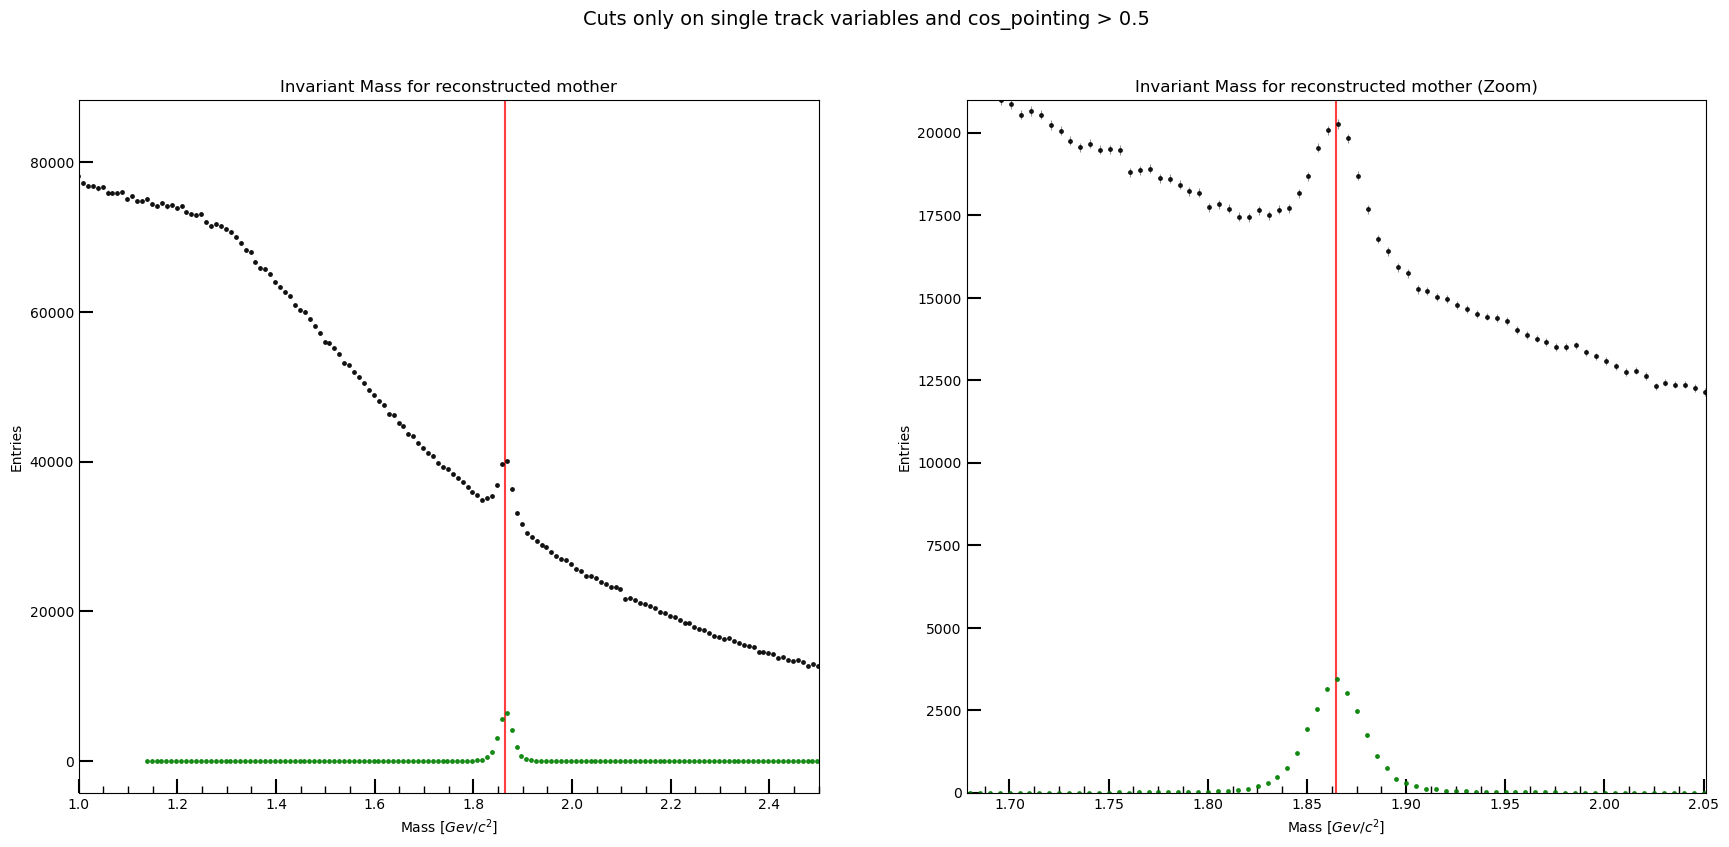

In [31]:
# define a function for the histograms appearence
def root_histo( ax, data, max_lim = None, min_lim = None, x_tick_loc = 2., x_tick_num = 4, box_c = [ 0.75, 0.7, 0.1, 0.2 ], step = 0.1, points_color = 'black', table_title = "Statistics" ) :
    
    if max_lim == None: max_lim + data.max()
    if min_lim == None: min_lim + data.min()

    bin_edges = np.arange( start = data.min(), stop = data.max(), step = step )
    hist, bin_edges = np.histogram( a = data, bins = bin_edges )
    errors = np.sqrt( hist )
    x_values = ( bin_edges[:-1] + bin_edges[1:] ) / 2.
    ax.errorbar( x = x_values , y = hist, yerr = errors, alpha=0.85, color=points_color, ecolor='gray', elinewidth=0.75, fmt='o', markersize=2.5, label = 'data' )
    ax.set_xlim( min_lim, max_lim )
    #ax.set_yscale('log')
    ax.xaxis.set_major_locator(MultipleLocator(x_tick_loc))
    ax.xaxis.set_minor_locator(AutoMinorLocator(x_tick_num))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    '''
    ax.table( 
        cellText = [[f"{data.shape[0]}"],[ f"{data[data < max_lim].mean():.4f}"], [f"{data[data < max_lim].std():.4f}"], [f"{data[data < min_lim ].shape[0]}"], [f"{data[data > max_lim].shape[0]}"] ],
        rowLabels = [ 'Entries', 'Mean', 'Std Dev', 'Underflow', 'Overflow'],
        bbox = box_c,
        edges = 'open',
        rowLoc = 'left',
        )
    '''
    '''
    table = ax.table( 
        cellText = [ [f"{data.shape[0]}"], 
                     [f"{data[(data >= min_lim) & (data <= max_lim)].mean():.4f}"], 
                     [f"{data[(data >= min_lim) & (data <= max_lim)].std():.4f}"], 
                     [f"{(data < min_lim).sum()}"], [f"{(data > max_lim).sum()}"] ], 
        rowLabels = ['Entries', 'Mean', 'Std Dev', 'Underflow', 'Overflow'], 
        bbox = box_c,  
        rowLoc = 'left' 
    )  
        
    ax.text( 
        box_c[0] + box_c[2]/2, 
        box_c[1] + box_c[3] + 0.02, 
        table_title, 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold', 
    transform=ax.transAxes 
    )
    '''
    return ( hist, x_values )
#-----------------------------------------------------------------------------------------------------------   
# Plot the invariant mass for the reconstructed particles without cuts on couple variables

filtered_masses = np.concatenate([final_results[final_results["hyp"]=="D0"]["inv_mass"],
                                  final_results[final_results["hyp"]=="Anti-D0"]["anti_mass"],
                                  final_results[final_results["hyp"]=="Undecided"]["anti_mass"],
                                  final_results[final_results["hyp"]=="Undecided"]["inv_mass"]])
'''
fig, ax = plt.subplots(1,2, figsize=(21,9) )
MASS_MIN, MASS_MAX = 1, 2.5
binwidth = 0.01
ax[0].hist(filtered_masses,range=(MASS_MIN,MASS_MAX), bins=np.arange(MASS_MIN, MASS_MAX+binwidth,binwidth))
ax[0].axvline(x=m_d0, color="red", alpha=0.5)
ax[0].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[0].set_ylabel(f"Counts per {binwidth*1000:.1f} $MeV/c^2$")
ax[0].set_title(f"Invariant mass")
lim_y = ax[0].get_ylim()

M_min, M_max = 0.9*m_d0, 1.1*m_d0
binwidth_zoom = 0.005
ax[1].hist(filtered_masses,range=(M_min,M_max), bins=np.arange(M_min, M_max+binwidth_zoom,binwidth_zoom))
ax[1].axvline(x=m_d0, color="red", alpha=0.5)
ax[1].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[1].set_ylabel(f"Counts per {(binwidth*1000):.1f} $MeV/c^2$")
ax[1].set_title(f"Invariant mass")
#plt.savefig("Maybe.png")
lim_y_zoom = ax[1].get_ylim()
plt.show()
'''

MASS_MIN, MASS_MAX = 1, 2.5
binwidth = 0.01


fig, axs = plt.subplots( nrows = 1, ncols = 2, figsize = ( 21, 9  ) )
_ = root_histo( axs[0], data=filtered_masses, max_lim = MASS_MAX , min_lim = MASS_MIN ,step = binwidth,
                box_c = [ 0.75, 0.7, 0.1, 0.2 ], x_tick_loc = 0.2, table_title = "Reco-stat" )

axs[0].set_title( "Invariant Mass for reconstructed mother" )
axs[0].set_xlabel( r"Mass $[Gev/c^2]$")
axs[0].set_ylabel( r"Entries")
axs[0].axvline(x=m_d0, color="red", alpha=0.5)
lim_y = axs[0].get_ylim()
axs[0].set_ylim(lim_y)

M_min, M_max = 0.9*m_d0, 1.1*m_d0
binwidth_zoom = 0.005

_ = root_histo( axs[1], data=filtered_masses, max_lim = M_max, min_lim = M_min, step=binwidth_zoom,
                box_c = [ 0.75, 0.3, 0.1, 0.13 ], x_tick_loc = 0.05, table_title = "Reco-stat" )
axs[1].set_title( "Invariant Mass for reconstructed mother" )
axs[1].set_xlabel( r"Mass $[Gev/c^2]$")
axs[1].set_ylabel( r"Entries" )
axs[1].axvline(x=m_d0, color="red", alpha=0.5)
lim_y_zoom = axs[1].get_ylim()
axs[1].set_ylim(lim_y_zoom)
#plt.show()

filtered_masses_MC = np.concatenate([final_results[final_results["truth"]==1]["inv_mass"],
                                      final_results[final_results["truth"]==-1]["anti_mass"]])
                                  
#fig, axs = plt.subplots( nrows = 1, ncols = 2, figsize = ( 21, 9  ) )
_ = root_histo( axs[0], data=filtered_masses_MC, max_lim = MASS_MAX , min_lim = MASS_MIN ,step = binwidth,
                box_c = [0.2, 0.1, 0.1, 0.25], x_tick_loc = 0.2, points_color = 'green', table_title = "MC-stat" )
axs[0].set_title( "Invariant Mass for reconstructed mother" )
axs[0].set_xlabel( r"Mass $[Gev/c^2]$")
axs[0].set_ylabel( r"Entries")
axs[0].axvline(x=m_d0, color="red", alpha=0.5)
lim_y = axs[0].get_ylim()
axs[0].set_ylim(lim_y)

_ = root_histo( axs[1], data=filtered_masses_MC, max_lim = M_max, min_lim = M_min, step=binwidth_zoom,
                box_c = [0.2, 0.1, 0.1, 0.13], x_tick_loc = 0.05, points_color = 'green', table_title = "MC-stat" )
axs[1].set_title( "Invariant Mass for reconstructed mother (Zoom)" )
axs[1].set_xlabel( r"Mass $[Gev/c^2]$")
axs[1].set_ylabel( r"Entries" )
axs[1].axvline(x=m_d0, color="red", alpha=0.5)
lim_y = axs[1].get_ylim()
axs[1].set_ylim(0, 21000)

fig.suptitle("Cuts only on single track variables and cos_pointing > 0.5", fontsize=14)
plt.show()






<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_9838/1288701099.py:19: SyntaxWarning: invalid escape sequence '\o'
  ax.set_title("Invariant Mass for reconstructed $D_0/\overline{D_0}$")


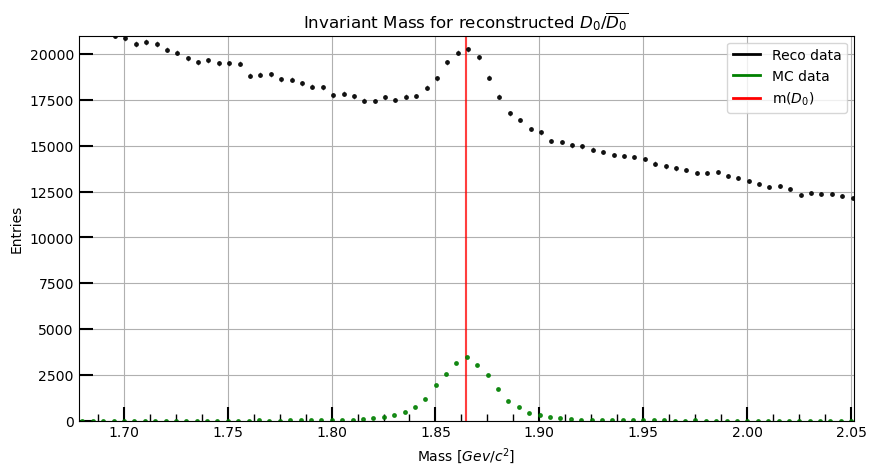

In [46]:
fig_presentation, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5)) 
_ = root_histo(ax, data=filtered_masses, max_lim=M_max, min_lim=M_min, step=binwidth_zoom, 
               box_c=[0.75, 0.3, 0.1, 0.13], 
               x_tick_loc=0.05, table_title="Reco-stat") 

ax.set_title("Invariant Mass for reconstructed r'$D_0$'") 
ax.set_xlabel(r"Mass $[Gev/c^2]$") 
ax.set_ylabel(r"Entries") 
ax.axvline(x=m_d0, color="red", alpha=0.5) 
lim_y_zoom = ax.get_ylim() 
ax.set_ylim(lim_y_zoom) 

_ = root_histo(ax, data=filtered_masses_MC, 
               max_lim=M_max, min_lim=M_min,
               step=binwidth_zoom, 
               box_c=[0.2, 0.1, 0.1, 0.13], 
               x_tick_loc=0.05, points_color='green', 
               table_title="MC-stat") 
ax.set_title("Invariant Mass for reconstructed $D_0/\overline{D_0}$") 
ax.set_xlabel(r"Mass $[Gev/c^2]$") 
ax.set_ylabel(r"Entries") 
ax.axvline(x=m_d0, color="red", alpha=0.5) 
ax.set_ylim(0, 21000) 
plt.grid()

from matplotlib.lines import Line2D 
legend_elements = [ Line2D([0], [0], color='black', lw=2, label='Reco data'), Line2D([0], [0], color='green', lw=2, label='MC data'), Line2D([0], [0], color='red', lw=2, label='m($D_0$)') ] 
ax.legend(handles=legend_elements)


plt.show()
fig_presentation.savefig("MC_reco_hist.png", dpi=300, bbox_inches="tight")

A questo punto il dataframe ha subito solo un taglio sul coseno di pointing molto largo (>0.5) per questione di meorizzaione dei dati. Ha le colonne per effettuare i tagli sulle variabili di coppia DCA, coseno di pointing, decay_length. La colonne $hyp$ contiene l'identita' della particella madre ipotizzata sulla base dei tagli di particella singola positiva e negativa e della ipotesi sulla loro natura di kaoni o pioni. La colonna $truth$ invece contiene la vera natura della particella sulla base delle informazioni monte carlo. Le cose da fare ora sono:
- Filtrare il dataframe come se fossero dati, ovvero eliminare tutte le particelle che sono state ipotizzate come $Bkg$, selezionare delle rimanenti solo quelle con $pt$ compreso tra 2 e 8.
- Filtrare con i tagli di coppia.
- Contare delle rimanenti quante sono effettivamente segnale avvalendosi della colonna $truth$ e contarle
- Contare le generate in MC in questo intervallo di Pt e fare il rapporto.

At this point, the data frame has only undergone a very large pointing cosine cut (>0.3) for data storage purposes. It has columns for making cuts on the DCA pair variables, pointing cosine, and decay_length. The $hyp$ column contains the identity of the hypothesized parent particle based on the positive and negative single particle cuts and the hypothesis of their nature as kaons or pions. The $truth$ column, on the other hand, contains the true nature of the particle based on the Monte Carlo information. The steps to take now are:
- Filter the data frame as if it were data, that is, eliminate all particles hypothesized as $Bkg$, and select only those with $pt$ between 2 and 8.
- Filter using the pair cuts.
- Count how many of the remaining particles are actually signals using the $truth$ column and count them.
- Count the particles generated in MC in this Pt range and calculate the ratio.



# Global efficiency 

In [13]:
# remove the partcles labeles as background
filtered_df = final_results[(final_results["hyp"] != "Bkg")]
print("The particles labeled as signal are: ", len(filtered_df))

The particles labeled as signal are:  9284352


In [14]:
# cuts on couple variables
filtered_df = filtered_df[(filtered_df["cos_pointing"] > 0.98) & (filtered_df["dcaXY_product"] < -2e-05)]
print("After cut on cos_pointing and dca:", len(filtered_df))

After cut on cos_pointing and dca: 339904


In [15]:
# How many particle there are in the dataframe now?
reco_D0 = len(filtered_df[filtered_df["truth"]==1] )
reco_anti_D0 = len(filtered_df[filtered_df["truth"]==-1] )
reco_par = reco_D0 + reco_anti_D0
print(f"In the data there are {reco_D0} D0 and {reco_anti_D0} anti-D0 => {reco_par} reconstructed particles ")

In the data there are 3000 D0 and 3213 anti-D0 => 6213 reconstructed particles 


In [16]:

def binom_err(k,N):
    s = (k/N**2)*(1-k/N)
    return math.sqrt(s)
    

In [17]:
reco_par

6213

In [18]:
err = binom_err(reco_par, tot_gen_part)
eff = reco_par/tot_gen_part
print("Efficiency:", format(eff*100, ".3g"), "+/-", format(err*100, ".1g"), "%")

Efficiency: 1.89 +/- 0.02 %


# Efficiency Vs $p_t$ Intervals

In [19]:
filtered_df_pt = final_results[(final_results["hyp"] != "Bkg")] 
#filtered_df = final_results[final_results["pt"].between(3,5)]
len(filtered_df_pt)

9284352

In [20]:

multiple_masks_pt = [ 
    filtered_df_pt["pt"].between(Pt_intervals[0], Pt_intervals[1]), 
    filtered_df_pt["pt"].between(Pt_intervals[1], Pt_intervals[2]),
    filtered_df_pt["pt"].between(Pt_intervals[2], Pt_intervals[3]),
    filtered_df_pt["pt"].between(Pt_intervals[3], Pt_intervals[4]),
    filtered_df_pt["pt"].between(Pt_intervals[3], Pt_intervals[5])
]

# let's define the cuts for each pt window from th notebook "New_cuts_pair_variables.ipynb"
# cuts from telegram chat with Mattia
cuts_config = [
    # pt ∈ [0, 1]
    dict(
        cos_pointing = 0.4162
        #dcaXY_product = -4.0e-05,
        #decay_length = 0.0069
    ),
    
    # pt ∈ [1, 3]
    dict(
        cos_pointing = 0.7066,
        dcaXY_product = -1.536e-05
        #decay_length = 0.0069
    ),
    
    # pt ∈ [3, 5]
    dict(
        cos_pointing = 0.9722,
        dcaXY_product = -2.194e-05,
        decay_length = 0.0068
    ),

    # pt ∈ [5, 8]
    dict(
        cos_pointing = 0.9843,
        dcaXY_product = -1.746e-05,
        decay_length = 0.0116
    ),

    # pt ∈ [8, 16]
    dict(
        cos_pointing = 0.9856,
        dcaXY_product = -0.737e-05,
        decay_length = 0.0089
    )
]

In [21]:
# build pt-dependent cuts
cuts_per_pt = []

for pt_mask, cfg in zip(multiple_masks_pt, cuts_config):

    cut = pt_mask.copy()

    if "cos_pointing" in cfg:
        cut &= final_results["cos_pointing"] > cfg["cos_pointing"]
    if "dcaXY_product" in cfg:
        cut &= final_results["dcaXY_product"] < cfg["dcaXY_product"]
    if "decay_length" in cfg:
        cut &= final_results["decay_length"] > cfg["decay_length"]

    cuts_per_pt.append(cut)

# let's make a big OR over cuts:
cuts = cuts_per_pt[0]
for cut_pt in cuts_per_pt[1:]: cuts = cuts | cut_pt


In [22]:
# final cutted dataframe
reco_pt = filtered_df_pt[cuts]

In [23]:
len(reco_pt)

3547471

In [24]:
# tagli di coppia uguali a quelli fatti sui dati
#filtered_df = filtered_df[(filtered_df["cos_pointing"] > 0.98) & (filtered_df["dcaXY_product"] < -2e-05)]
#filtered_df = filtered_df[(filtered_df["cos_pointing"] > 0.92)]
#len(filtered_df)

In [25]:
# Quante D0 e anti-D0 sono rimaste secondo MC nei dati cosi' filtrati?
reco_D0 = len(reco_pt[reco_pt["truth"]==1] )
reco_anti_D0 = len(reco_pt[reco_pt["truth"]==-1] )
reco_par = reco_D0 + reco_anti_D0
print(f"In the data there are {reco_D0} D0 and {reco_anti_D0} anti-D0 => {reco_par} reconstructed particles ")

In the data there are 5459 D0 and 5926 anti-D0 => 11385 reconstructed particles 


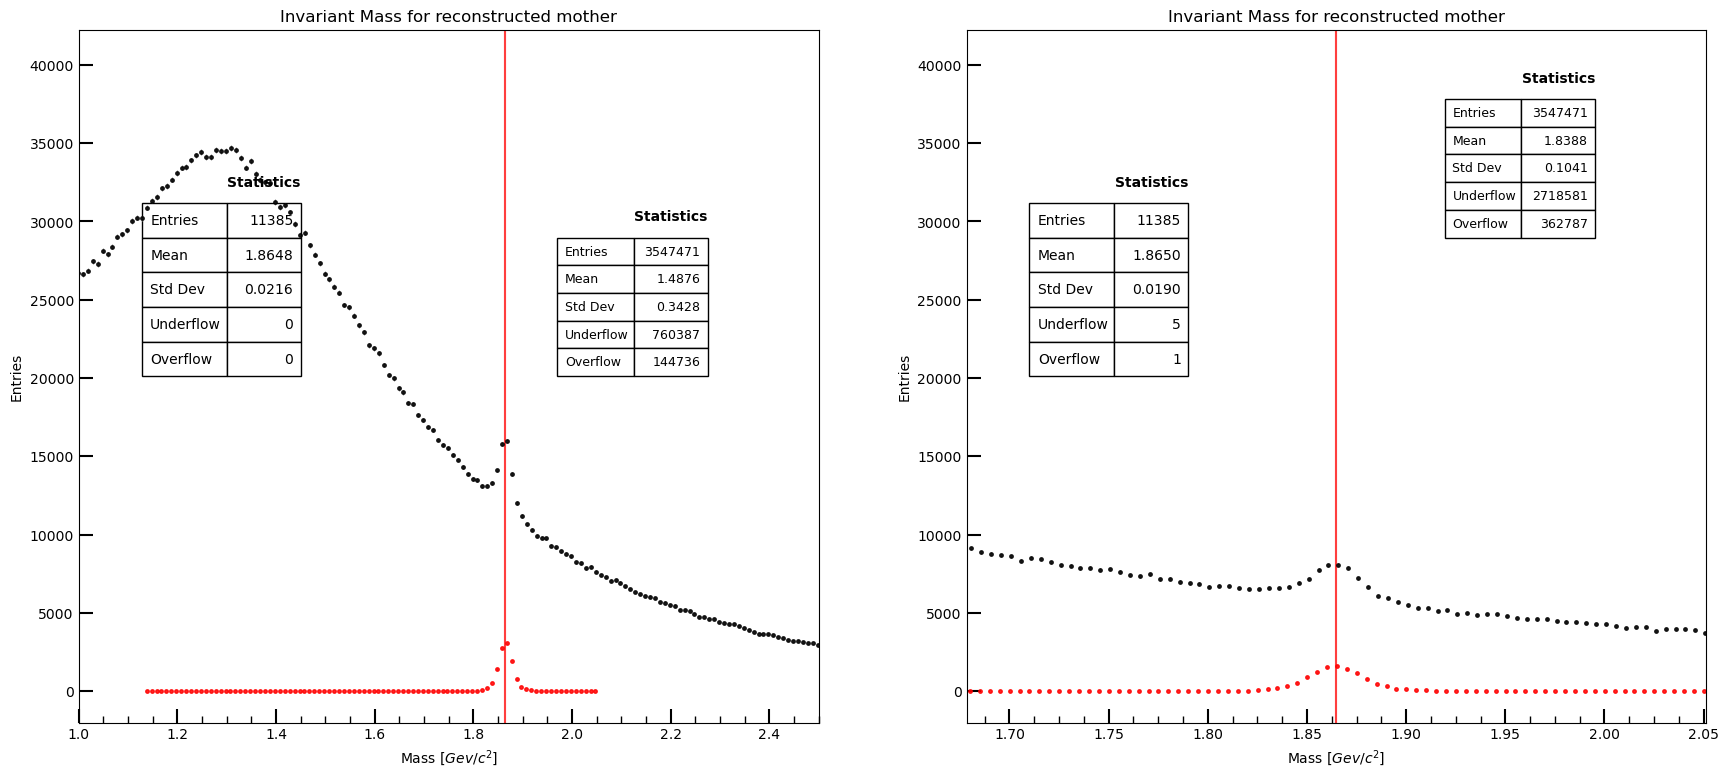

In [26]:

reco_sig_masses = np.concatenate([reco_pt[reco_pt["hyp"]=="D0"]["inv_mass"],
                                  reco_pt[reco_pt["hyp"]=="Anti-D0"]["anti_mass"],
                                  reco_pt[reco_pt["hyp"]=="Undecided"]["anti_mass"]])

'''
fig, ax = plt.subplots(1,2, figsize=(21,9) )
MASS_MIN, MASS_MAX = 1, 2.5
binwidth = 0.01
ax[0].hist(reco_sig_masses,range=(MASS_MIN,MASS_MAX), bins=np.arange(MASS_MIN, MASS_MAX+binwidth,binwidth))
ax[0].axvline(x=m_d0, color="red", alpha=0.5)
ax[0].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[0].set_ylabel(f"Counts per {binwidth*1000:.1f} $MeV/c^2$")
ax[0].set_title(f"Invariant mass")
lim_y = ax[0].get_ylim()

M_min, M_max = 0.9*m_d0, 1.1*m_d0
binwidth_zoom = 0.005
ax[1].hist(reco_sig_masses,range=(M_min,M_max), bins=np.arange(M_min, M_max+binwidth_zoom,binwidth_zoom))
ax[1].axvline(x=m_d0, color="red", alpha=0.5)
ax[1].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[1].set_ylabel(f"Counts per {(binwidth*1000):.1f} $MeV/c^2$")
ax[1].set_title(f"Invariant mass")
#plt.savefig("Maybe.png")
lim_y_zoom = ax[1].get_ylim()
plt.show()
'''

fig, axs = plt.subplots( nrows = 1, ncols = 2, figsize = ( 21, 9  ) )
_ = root_histo( axs[0], data=reco_sig_masses, max_lim = MASS_MAX , min_lim = MASS_MIN ,step = binwidth,
                box_c = [ 0.75, 0.5, 0.1, 0.2 ], x_tick_loc = 0.2 )
axs[0].set_title( "Invariant Mass for reconstructed mother" )
axs[0].set_xlabel( r"Mass $[Gev/c^2]$")
axs[0].set_ylabel( r"Entries")
axs[0].axvline(x=m_d0, color="red", alpha=0.5)
axs[0].set_ylim(lim_y)

_ = root_histo( axs[1], data=reco_sig_masses, max_lim = M_max, min_lim = M_min, step=binwidth_zoom,
                box_c = [ 0.75, 0.7, 0.1, 0.2 ], x_tick_loc = 0.05 )
axs[1].set_title( "Invariant Mass for reconstructed mother" )
axs[1].set_xlabel( r"Mass $[Gev/c^2]$")
axs[1].set_ylabel( r"Entries" )
axs[1].axvline(x=m_d0, color="red", alpha=0.5)
axs[1].set_ylim(lim_y_zoom)
#plt.show()

reco_sig_masses_MC = np.concatenate([reco_pt[reco_pt["truth"]==1]["inv_mass"],
                                      reco_pt[reco_pt["truth"]==-1]["anti_mass"]])
                                  
#fig, axs = plt.subplots( nrows = 1, ncols = 2, figsize = ( 21, 9  ) )
_ = root_histo( axs[0], data=reco_sig_masses_MC, max_lim = MASS_MAX , min_lim = MASS_MIN ,step = binwidth,
                box_c = [0.2, 0.5, 0.1, 0.25], x_tick_loc = 0.2, points_color = 'red' )
axs[0].set_title( "Invariant Mass for reconstructed mother" )
axs[0].set_xlabel( r"Mass $[Gev/c^2]$")
axs[0].set_ylabel( r"Entries")
axs[0].axvline(x=m_d0, color="red", alpha=0.5)
axs[0].set_ylim(lim_y)

_ = root_histo( axs[1], data=reco_sig_masses_MC, max_lim = M_max, min_lim = M_min, step=binwidth_zoom,
                box_c = [0.2, 0.5, 0.1, 0.25], x_tick_loc = 0.05, points_color = 'red' )
axs[1].set_title( "Invariant Mass for reconstructed mother" )
axs[1].set_xlabel( r"Mass $[Gev/c^2]$")
axs[1].set_ylabel( r"Entries" )
axs[1].axvline(x=m_d0, color="red", alpha=0.5)
axs[1].set_ylim(lim_y_zoom)
plt.show()


In [27]:
eff_num_pt = []

for i in range(len(Pt_intervals)-1):
    reco_count = len(reco_pt[(reco_pt["pt"].between(Pt_intervals[i], Pt_intervals[i+1]) 
                    & ((reco_pt["truth"]==1)|(reco_pt["truth"]==-1)))])
    eff_num_pt.append(reco_count)

print(eff_num_pt)
print(sum(eff_num_pt))

[2569, 5274, 2208, 1203, 131]
11385


In [28]:
g_pt=tot_part
print(g_pt["tot"])

0     69724.0
1    166696.0
2     61498.0
3     23331.0
4      7589.0
Name: tot, dtype: float64


In [29]:
# Calculate efficiency and errors Vs pt
efficiency_pt = eff_num_pt/g_pt["tot"]

# Calculate the error
eff_err_pt=[]
for r,g in zip(eff_num_pt,g_pt["tot"]):
    e = binom_err(r,g)
    eff_err_pt.append(e)
    
print( [e*100 for e in efficiency_pt] )
print( [a*100 for a in eff_err_pt] )

[3.684527565830991, 3.1638431636032056, 3.590360662135354, 5.156229908705156, 1.7261826327579393]
[0.07134241188664511, 0.04287100421415669, 0.07502375056521726, 0.14477843059334422, 0.14950991965461566]


# Raw yeld and efficiency curve

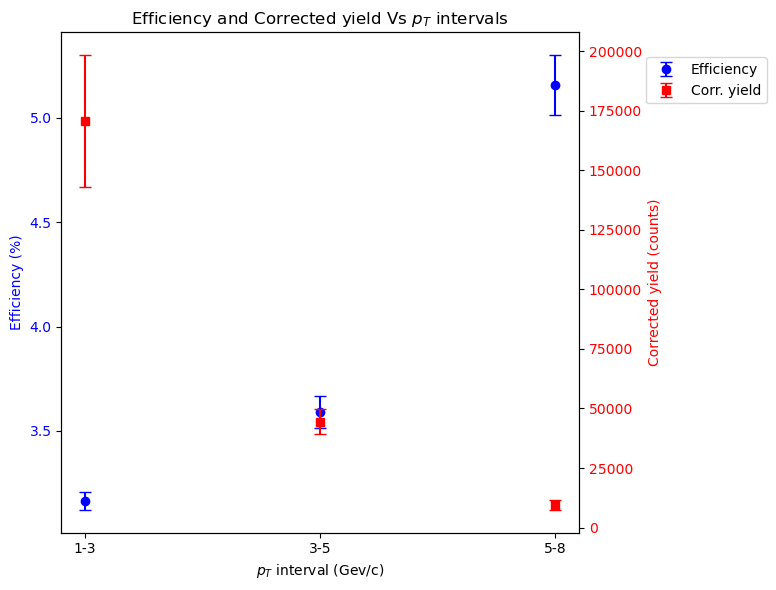

In [83]:
x_labels = ["1-3", "3-5", "5-8"]
raw_yeld = np.array([5397, 1598, 491])
raw_yield_err = np.array([874, 185, 109])
x = np.arange(len(x_labels)) 
eff = np.array([3.1638431636032056, 3.590360662135354, 5.156229908705156]) 
err_eff = np.array([0.04287100421415669, 0.07502375056521726, 0.14477843059334422]) 
corr_yield = np.array(raw_yeld/(eff/100)) 
err_c_y = np.array([ corr_yield*(((err_eff/eff)**2+(raw_yield_err/raw_yeld)**2))**(1/2) ]) 

fig, ax1 = plt.subplots(figsize=(8, 6)) 

# first x axis 
ax1.errorbar( x, eff, yerr=err_eff, fmt='o', color='blue', capsize=4, label='Efficiency' ) 
ax1.set_xlabel("$p_T$ interval (Gev/c)") 
ax1.set_ylabel("Efficiency (%)", color='blue') 
ax1.tick_params(axis='y', labelcolor='blue') 

# second y axis
ax2 = ax1.twinx() 
ax2.errorbar( x, corr_yield, yerr=err_c_y, fmt='s', color='red', capsize=4, label='Corr. yield' ) 
ax2.set_ylabel("Corrected yield (counts)", color='red') 
ax2.tick_params(axis='y', labelcolor='red') 

#x labels
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels)

# legend
lines1, labels1 = ax1.get_legend_handles_labels() 
lines2, labels2 = ax2.get_legend_handles_labels() 
ax1.legend(lines1 + lines2, 
           labels1 + labels2, 
           loc='upper left',
           bbox_to_anchor=(1.13, 0.95), 
           borderaxespad=0.
          ) 

plt.title("Efficiency and Corrected yield Vs $p_T$ intervals") 
plt.tight_layout() 
plt.show() 

In [84]:
fig.savefig("eff_and_yield.png", dpi=300, bbox_inches="tight")